<a href="https://colab.research.google.com/github/oscarserc/TESIS/blob/main/PASO_3f___GNN____grid28x28_2Conv_LSTM__Pruebas_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**UTILIZACIÓN DE TÉCNICAS DE APRENDIZAJE AUTOMÁTICO PARA LA DETECCIÓN DE LOS NODOS CONFLICTIVOS EN UNA RED SOCIAL**.

La base de datos que emplearemos puede llegar a unas 12.000 observaciones. El tamaño crece rápidamente. Por ejemplo 4000 observaciones son aproximadamente 50 MB.

· Pruebas iniciales con: 4.000 observaciones

· Para ello generamos una 100 **simulaciones**, y guardamos unos 40 **frames** de cada una de ellas

· Además como **target** guardamos la matriz con la IDENTIDAD de todos y cada uno de los AGENTES.




# <b>PRUEBA</b>: Utilizaremos una <font color='green'>**RED de GRAFOS (GNN - *Graph Neural Network*)**</font>. Ahora le pasaremos secuencias de 40 frames. Inicialmente los patrones espaciales son tratados por 2 redes neuronales convolucionales (CNN), y posteriormente una red LSTM procesa las secuencias de embeddings de cada uno de los nodos de la red. Finalmente una capa lineal es la encargada de generar las máscaras de segmentación, que nos proporcionan (probabilísticamente) la identidad del agente que ocupa cada celda.



<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/GNN_Esquema_2Conv_LSTM_1h.png?raw=true' width="850"/>
<figcaption>fig. 1: Estructura de la red GNN (Graph Neural Network) que hemos implementado.</figcaption></center>
</figure>


El archivo de prueba contiene 12000 observaciones (*utilizaremos 4000 en algunos casos para acelerar las pruebas*). Las simulaciones de la población utilizan AGENTES EMOCIONALES, mezclados con AGENTES MUTANTES que acosan e intentan aprovecharse sistemáticamente del resto de jugadores vecinos. Éstos últimos se generan aleatoriamente según una variable aleatoria <font color="blue"><b>Bernuilli(p=0.15)</b></font>. Es decir, generamos en término medio un 15% de mutantes en cada jugada.


<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Archivo_E_CNN_target2_28x28_sinBarajar_b.png?raw=true' width="1000"/>
<figcaption></figcaption></center>
</figure>

<!--  Gráfico: Archivo_E_CNN_target2_28x28_sinBarajar_b.png
      Opción inicial: Matriz_BD_1b.png
-->




Con la base de datos anterior procederemos al entrenamiento de la red neuronal. El archivo no se aleatoriza en este caso, para así mantener el orden en el que han sido generados los datos durante la simulación.


#**CARGAMOS LA BASE DE DATOS**


In [ ]:

import pandas as pd

# Cargamos los datos   -  De entrada: 4000 ciclos y valor lambda = 1.0
# ------------------
bd_simulaciones = pd.read_csv('bd_100simulaciones_1000ciclos_LEARN_Pagos_y_Emocion_28x28_emo85_vs_15_10.csv')


In [ ]:

import pandas as pd

# LA BASE DE DATOS GENERAL CON LA QUE HICE LAS PRIMERAS PRUEBAS
# -------------------------------------------------------------
# 4000 ciclos
bd_simulaciones = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15.csv')
# 3000 ciclos
#bd_simulaciones = pd.read_csv('bd_100simulaciones_3000ciclos_28x28_emo85_vs_15.csv')
# 2000 ciclos
#bd_simulaciones = pd.read_csv('bd_100simulaciones_2000ciclos_28x28_emo85_vs_15.csv')
# 1000 ciclos
#bd_simulaciones = pd.read_csv('bd_100simulaciones_1000ciclos_28x28_emo85_vs_15.csv')




#<font color="brown">**1)** CONSTRUIMOS LA MATRIZ **X** CON TODOS los Frames</font>: (num_frames = 40), y vamos probando con todas las 100 SIMULACIONES

<font color="red">**simulaciones_list**</font> es la estructura que contiene TODA LA INFORMACIÓN FINAL


In [ ]:

import torch
import numpy as np
import pandas as pd # Ensure pandas is imported as it's used later

size             = 28
num_nodos        = size * size
num_frames       = 40
NUM_SIMULACIONES = 100

# Lista para almacenar un DATAFRAME para cada FRAME
simulaciones_Features_list = []

for simulacion_id in range(1,NUM_SIMULACIONES+1):
  BD_frames_list = [] # IMPORTANTE: Resetear para cada nueva simulacion

  # Filtramos el DataFrame para la simulación actual
  current_simulation_df = bd_simulaciones[bd_simulaciones['Simulacion_ID'] == simulacion_id]

  # Construimos base de datos para los NODOS con 3 valores: (R, G, B) para cada frame
  for frame_num in range(1,num_frames+1):
    # Find the row corresponding to the current frame in the current simulation's data
    # .iloc[0] is used because the filter will return a DataFrame with one row
    frame_row = current_simulation_df[current_simulation_df['Frame'] == frame_num].iloc[0]

    current_frame_data = [] # Data para los NODOS del FRAME actual

    # ==================
    #    X - FEATURES
    # ==================
    # LOS NODOS EMPIEZAN A CONTAR DESDE 0 ----> nodo 0, nodo 1, . . . , nodo 783
    for nodo in range(num_nodos):
      r_value = frame_row['r' + str(nodo)]
      g_value = frame_row['g' + str(nodo)]
      b_value = frame_row['b' + str(nodo)]
      current_frame_data.append([r_value, g_value, b_value])

    # Nombre de columnas para el FRAME ACTUAL
    column_names = ['R' + str(frame_num), 'G' + str(frame_num), 'B' + str(frame_num)]
    # Creamos un DATAFRAME para los datos del FRAME ACTUAL
    df_current_frame = pd.DataFrame(current_frame_data, columns=column_names)
    BD_frames_list.append(df_current_frame)

  # Concatenate all DataFrames horizontally to form the final DF for the current simulation
  DF = pd.concat(BD_frames_list, axis=1)
  simulaciones_Features_list.append(DF)
  # No need to explicitly clear DF = [] here, it will be overwritten in the next iteration



#<font color="brown">**2)** CONSTRUIMOS LA MATRIZ de Adyacencia **A**</font>


In [ ]:

# Función auxiliar para convertir coordenadas del GRID en
# número secuencial
# --------------------------------------------------------
def convertir_nodo(i,j):
  return i*size + j

# Tamaños y estructura de DATOS
# -----------------------------
size  = 28
NODOS = size*size
Adyacencia_ = np.zeros((NODOS,NODOS), dtype=int)

# -----------------------------------
# CONSTRUIMOS LA MATRIZ de ADYACENCIA
# -----------------------------------
for i in range(size):
  for j in range(size):
    nodo_inicial = convertir_nodo(i, j)

    # Iteramos por todos los nodos incluido uno mismo
    for di in [-1, 0, 1]:
      for dj in [-1, 0, 1]:
        # Si es el propio nodo lo saltamos
        if di == 0 and dj == 0:
          continue
        ni, nj = i + di, j + dj
        # Comprobamos que las celdas no se salen del grid
        if 0 <= ni < size and 0 <= nj < size:
          nodo_final = convertir_nodo(ni, nj)
          Adyacencia_[nodo_inicial, nodo_final] = 1



#<font color="brown">**3)** CONSTRUIMOS LA MATRIZ: **Y** </font> Con el TARGET de los respectivos frames que conforman la SIMULACION

In [ ]:

lista_targets = []
numero_frames = 40

simulaciones_Targets_list = []

NUM_SIMULACIONES = 100  # 100

for simulacion_id in range(1,NUM_SIMULACIONES+1):
    # Filter for the last frame of the current simulation_id
    # Note: bd_simulaciones.iloc['Simulacion_ID'== simulacion_id] was incorrect as .iloc uses integer-location based indexing.
    # Using boolean indexing for filtering by column value.
    filtered_row = bd_simulaciones[(bd_simulaciones['Simulacion_ID'] == simulacion_id) & (bd_simulaciones['Frame'] == numero_frames)]

    if not filtered_row.empty:
        # Extract the 'Target' string from the filtered row (assuming there's only one such row)
        lista_id_agentes = filtered_row.iloc[0]['Target'].replace('[','').replace(']','')
        target = [int(caracter) for caracter in lista_id_agentes.split(',')]
        target = np.array(target)

        # Reshape to a 2D array and convert to DataFrame
        Y_sim = pd.DataFrame(target.reshape(-1, 1), columns=['Target'])
        simulaciones_Targets_list.append(Y_sim)

# Assign the first DataFrame from simulacion_targets to global Y if available
if simulaciones_Targets_list:
    Y = simulaciones_Targets_list[0]
else:
    Y = pd.DataFrame() # Assign an empty DataFrame if no targets were found

lista_targets = [] # Clear lista_targets as it's no longer used for the final Y



#<font color="brown">**4)** PREPARAMOS LOS edge_index </font>, para que PyTorch Geometric tenga información de la topología del GRAFO

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/PyG_1a.png?raw=true' width="450"/>
</center>
</figure>

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.0 MB/s eta 0:00:00


In [ ]:

import torch
from torch_geometric.data import Data

size      = 28
num_nodos = size*size

nodos_origen = []
nodos_destino = []

for origen in range(num_nodos):
  for destino in range(num_nodos):
    if (Adyacencia_[origen][destino] == 1):
      nodos_origen.append(origen)
      nodos_destino.append(destino)

edge_index = torch.tensor([nodos_origen, nodos_destino], dtype=torch.long)



#<font color="brown">**5)** Ahora intentamos con la estructura DATA de PyTorch Geometric</font>


In [ ]:
import torch
from torch_geometric.data import Data

NUM_SIMULACIONES = 100 #100

# Lista para almacenar objetos Data, uno por cada simulación
dataset_final_grafos = []

for simulacion_idx in range(NUM_SIMULACIONES):
    # x contiene las características de todos los nodos a través de todos los frames para la simulación actual
    x_features = torch.tensor(simulaciones_Features_list[simulacion_idx].values, dtype=torch.float)
    # y contiene las etiquetas de target para todos los nodos de la simulación actual
    y_labels = torch.tensor(simulaciones_Targets_list[simulacion_idx].values, dtype=torch.long)

    # edge_index es global y representa la topología del grafo, que es constante
    grafo = Data(x=x_features, edge_index=edge_index, y=y_labels)
    dataset_final_grafos.append(grafo)



#**<font color="brown">6) DEFINICIÓN DEL MODELO:**</font> <font color="green"> **(2Conv + LSTM)**


In [ ]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import LSTM

# ------------------------
# Clase: GNN_Temporal_LSTM
# ------------------------

class GNN_Temporal_LSTM(torch.nn.Module):
  def __init__(self, node_features_per_frame, hidden_dim, num_classes, num_frames):
    super(GNN_Temporal_LSTM, self).__init__()
    self.num_frames = num_frames
    self.node_features_per_frame = node_features_per_frame

    # Definimos la dimensión_oculta_intermedia para las capas GCN
    hidden_dim_gcn_intermediate = hidden_dim * 2

    self.conv1 = GCNConv(node_features_per_frame, hidden_dim_gcn_intermediate)
    self.conv2 = GCNConv(hidden_dim_gcn_intermediate, hidden_dim)

    # Reemplazar GRU por LSTM
    self.lstm = LSTM(hidden_dim, hidden_dim, batch_first=True)
    self.clasificador = torch.nn.Linear(hidden_dim, num_classes)

  def forward(self, x_all_frames, edge_index):
    node_embeddigs = []
    for t in range(self.num_frames):
      x_frame_t = x_all_frames[:, t * self.node_features_per_frame : (t + 1) * self.node_features_per_frame]

      h = self.conv1(x_frame_t, edge_index)
      h = F.relu(h)

      h = self.conv2(h, edge_index)
      h = F.relu(h)

      node_embeddigs.append(h)

    combined = torch.stack(node_embeddigs, dim=1)

    # Pasar por LSTM. La salida de LSTM es (output, (h_n, c_n))
    # Solo necesitamos 'output' que contiene la secuencia de estados ocultos
    output, (h_n, c_n) = self.lstm(combined)

    # Usamos el estado oculto final para la clasificación
    final_node_embeddings = output[:, -1, :]

    # Aplicar el clasificador lineal
    logits = self.clasificador(final_node_embeddings)

    return logits


#<font color="brown">**Médodo de ENTRENAMIENTO**</color>

In [ ]:

from sklearn.metrics import accuracy_score

# Función SOFTMAX auxiliar
# ------------------------
def softmax(x):
  return F.softmax(x, dim=-1)

# Función de ENTRENAMIENTO (empleamos método ponderado)
# -----------------------------------------------------
def fit_gnn_temporal(model, grafos_training, grafos_val, epochs=10, log_each=1, class_weights=None):
  # Introducimos los pesos de clase para que tenga en cuenta la clase infrarepresentada
   criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
   optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

   l, acc         = [], []
   val_l, val_acc = [], []

   for e in range(1, epochs+1):
      _l, _acc = [], []
      model.train()
      for data in grafos_training:
        x, edge_index, y_true = data.x, data.edge_index, data.y
        y_true = y_true.squeeze()

        y_pred_logits = model(x, edge_index)
        loss = criterion(y_pred_logits, y_true)
        _l.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_probas = torch.argmax(softmax(y_pred_logits), axis=1)
        _acc.append(accuracy_score(y_true.cpu().numpy(), y_probas.detach().cpu().numpy()))

      l.append(np.mean(_l))
      acc.append(np.mean(_acc))
      if not e % log_each:
        print(f"Epoch {e}/{epochs} train_loss {l[-1]:.5f} train_acc {acc[-1]:.5f}")

      model.eval()
      _l_val, _acc_val = [], []
      with torch.no_grad():
        for data in grafos_val:
          x, edge_index, y_true = data.x, data.edge_index, data.y
          y_true = y_true.squeeze()

          y_pred_logits = model(x, edge_index)
          loss = criterion(y_pred_logits, y_true)
          _l_val.append(loss.item())

          y_probas = torch.argmax(softmax(y_pred_logits), axis=1)
          _acc_val.append(accuracy_score(y_true.cpu().numpy(), y_probas.cpu().numpy()))

      val_l.append(np.mean(_l_val))
      val_acc.append(np.mean(_acc_val))
      if not e % log_each:
        print(f"Epoch {e}/{epochs} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

   return {'epoch':list(range(1,epochs+1)), 'train_loss':l, 'train_acc': acc, 'val_loss': val_l, 'val_acc': val_acc}



#**INSTANCIAMOS EL MODELO y PREPARAMOS PARA GUARDAR EL HISTORIAL DE LA EJECUCIÓN**


#Primero calculamos las ponderaciones (utilizamos optimización ponderada)

In [ ]:

import torch
import numpy as np

# Contamos casos de cada clase
class_counts = Y['Target'].value_counts().sort_index()

total_samples = class_counts.sum()
num_classes = len(class_counts)

# Class weights (inversamente proporcional a las frecuencias)
# formula: total_samples / (num_classes * class_count)
# -----------------------------------------------------------
class_weights_np = total_samples / (num_classes * class_counts.values)

# Convertimos a tensores de PyTorch
# ---------------------------------
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print("Valores class-weights calculados:", class_weights)


Valores class-weights calculados: tensor([0.5681, 4.1702])


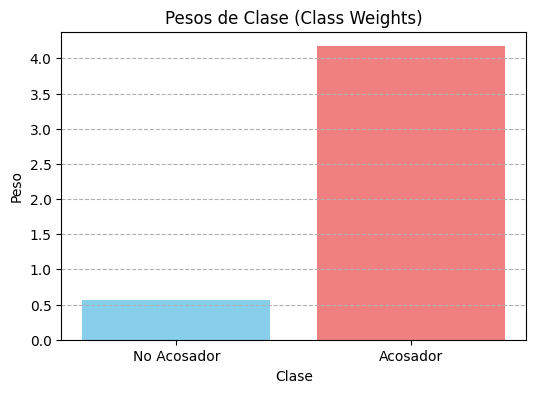

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert class_weights tensor to numpy for plotting
class_weights_np = class_weights.numpy()

# Labels for the x-axis
x_labels = ['No Acosador', 'Acosador']

# Create an array for the x-axis positions (e.g., 0, 1)
x_positions = np.arange(len(x_labels))

plt.figure(figsize=(6, 4)) # Optional: Adjust figure size
plt.bar(x_positions, class_weights_np, tick_label=x_labels, color=['skyblue', 'lightcoral'])

plt.xlabel('Clase')
plt.ylabel('Peso')
plt.title('Pesos de Clase (Class Weights)')
plt.grid(axis='y', linestyle='--')
plt.show()

#Dividimos los DATOS en TRAINING y VALIDACIÓN

In [ ]:

from sklearn.model_selection import train_test_split

# DIVIDIMOS EL DATASET EN: Datos de Training y Datos de Test
# ----------------------------------------------------------
grafos_training, grafos_val = train_test_split(
    dataset_final_grafos, test_size=0.2, random_state=42
)


#Instanciamos el MODELO y guardamos el hístorico de la ejecución

In [ ]:

num_frames = 40

# INSTANCIAMOS EL MODELO
# ----------------------
modelo_gnn_temporal_lstm = GNN_Temporal_LSTM(
    node_features_per_frame=3,
    hidden_dim=10,
    num_classes=2,
    num_frames=num_frames
)

# Entrenamos con ENTROPÍA CRUZADA ponderada, para
# asegurarnos que la clase infrarepresentada se tiene en cuenta
# --------------------------------------------------------------
historial_gnn_temporal_lstm = fit_gnn_temporal(
    modelo_gnn_temporal_lstm,
    grafos_training,
    grafos_val,
    epochs=50,
    class_weights=class_weights
)


Epoch 1/50 train_loss 0.65265 train_acc 0.23954
Epoch 1/50 val_loss 0.56468 val_acc 0.65542
Epoch 2/50 train_loss 0.52226 train_acc 0.66561
Epoch 2/50 val_loss 0.50589 val_acc 0.64911
Epoch 3/50 train_loss 0.48676 train_acc 0.64791
Epoch 3/50 val_loss 0.47727 val_acc 0.64082
Epoch 4/50 train_loss 0.46111 train_acc 0.67457
Epoch 4/50 val_loss 0.45255 val_acc 0.62889
Epoch 5/50 train_loss 0.39094 train_acc 0.73874
Epoch 5/50 val_loss 0.33735 val_acc 0.78080
Epoch 6/50 train_loss 0.33720 train_acc 0.78465
Epoch 6/50 val_loss 0.36631 val_acc 0.68712
Epoch 7/50 train_loss 0.31732 train_acc 0.79794
Epoch 7/50 val_loss 0.29534 val_acc 0.81754
Epoch 8/50 train_loss 0.29835 train_acc 0.80773
Epoch 8/50 val_loss 0.28914 val_acc 0.83712
Epoch 9/50 train_loss 0.28704 train_acc 0.81430
Epoch 9/50 val_loss 0.27838 val_acc 0.83980
Epoch 10/50 train_loss 0.27931 train_acc 0.81872
Epoch 10/50 val_loss 0.26984 val_acc 0.83163
Epoch 11/50 train_loss 0.27140 train_acc 0.82248
Epoch 11/50 val_loss 0.26461 

#Comprobamos la estructura del modelo que hemos generado

In [ ]:

#  FORMA 1
# ---------

from torchsummary import summary

# modelo  = GNN_Temporal_LSTM(3,10,2,40)
# summary(modelo, (3, 28, 28))


In [ ]:

!pip install torchinfo


In [ ]:

#  FORMA 2  (forma más moderna)
# ---------

from torchinfo import summary
import torch

modelo  = GNN_Temporal_LSTM(3,10,2,40)

# Create dummy input tensors for the summary
# x_all_frames should be (num_nodes, num_frames * node_features_per_frame)
# num_nodos is 784 (28*28), num_frames is 40, node_features_per_frame is 3
dummy_x = torch.randn(784, 40 * 3)

# edge_index is already a global tensor

# Se pasan los inputs como una lista de argumentos
summary(modelo, input_data=[dummy_x, edge_index])


Layer (type:depth-idx)                   Output Shape              Param #
GNN_Temporal_LSTM                        [784, 2]                  --
├─GCNConv: 1-1                           [784, 20]                 20
│    └─Linear: 2-1                       [784, 20]                 60
│    └─SumAggregation: 2-2               [784, 20]                 --
├─GCNConv: 1-2                           [784, 10]                 10
│    └─Linear: 2-3                       [784, 10]                 200
│    └─SumAggregation: 2-4               [784, 10]                 --
├─GCNConv: 1-3                           [784, 20]                 (recursive)
│    └─Linear: 2-5                       [784, 20]                 (recursive)
│    └─SumAggregation: 2-6               [784, 20]                 --
├─GCNConv: 1-4                           [784, 10]                 (recursive)
│    └─Linear: 2-7                       [784, 10]                 (recursive)
│    └─SumAggregation: 2-8               [784, 1

#<font color="brown">**7) Representamos GRÁFICAMENTE los resultados del ENTRENAMIENTO**</font>

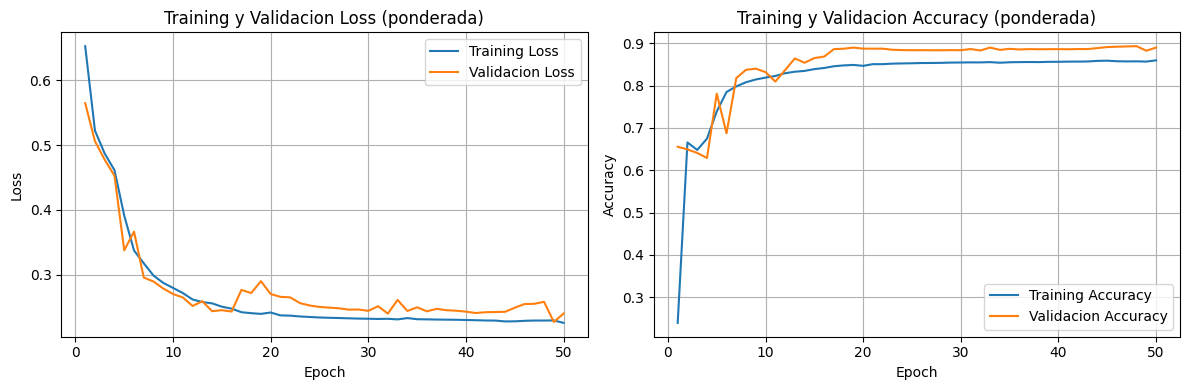

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

# Convertimos el histórico de ejecución (diccionario)
# en un DataFrame de pandas para dibujarlo
# ----------------------------------------------------
history_df = pd.DataFrame(historial_gnn_temporal_lstm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
# ---------
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Training Loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validacion Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training y Validacion Loss (ponderada)')
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
# -------------
axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Training Accuracy')
axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Validacion Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training y Validacion Accuracy (ponderada)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



#<font color="brown">**8) EVALUAMOS EL CLASIFICADOR**</font>



Results for (LSTM) model with num_frames=40:
  Final Training Loss: 0.2253
  Final Training Accuracy: 0.8594
  Final Validation Loss: 0.2397
  Final Validation Accuracy: 0.8896


 RESUMEN GLOBAL
----------------
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     13323
           1       0.58      0.92      0.71      2357

    accuracy                           0.89     15680
   macro avg       0.78      0.90      0.82     15680
weighted avg       0.92      0.89      0.90     15680

  Confusion Matrix:
--------------------
    [11791, 1532]
    [199, 2158]


  Class 1 F1-score: 0.7137
  Validation ROC AUC: 0.9579




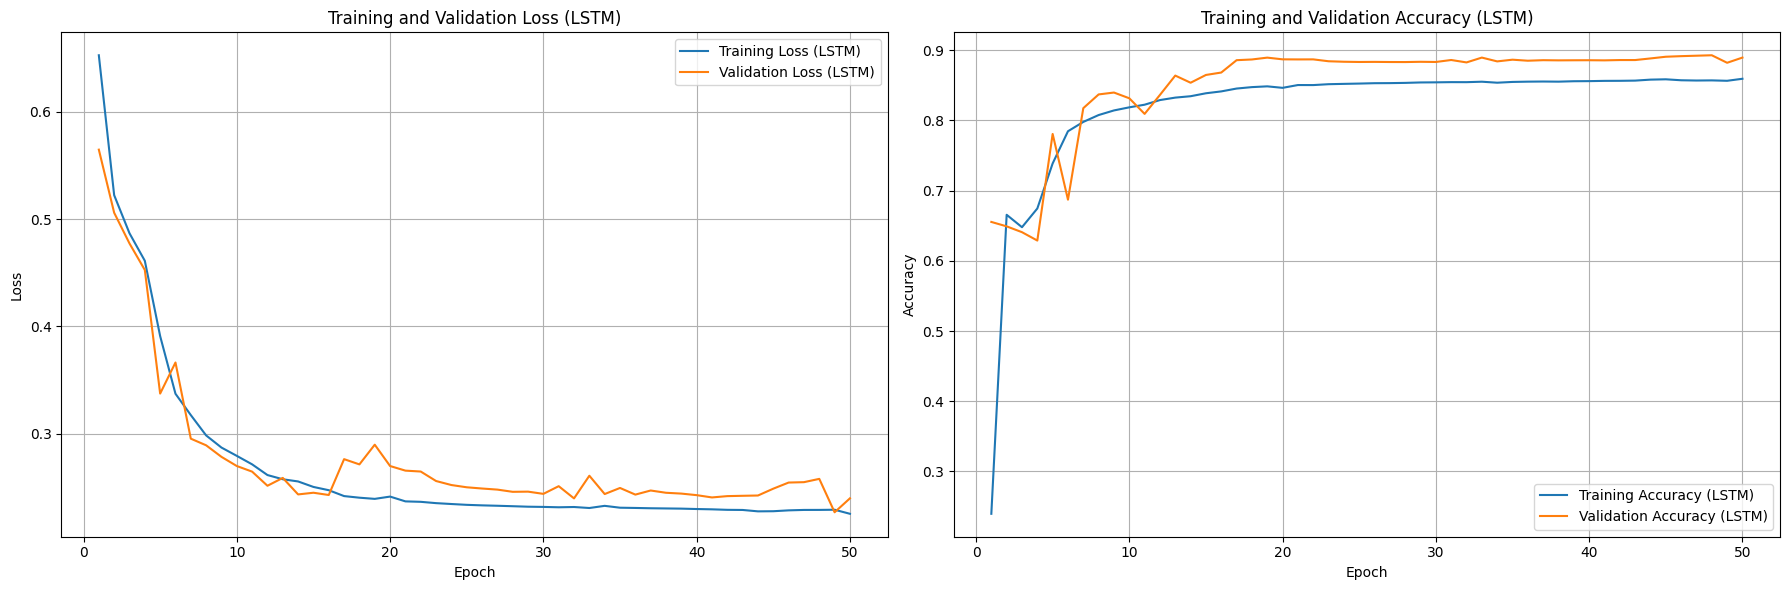

In [ ]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

# PONEMOS EL MODELO EN MODO EVALUACIÓN - dejamos explícitamente congelados
# los valores de los parámetros
modelo_gnn_temporal_lstm.eval()
all_y_true = []
# Scores previos a la predicción de clase para calcular la curva ROC
all_y_pred_scores = []
all_y_pred_classes = []

with torch.no_grad():
    for data in grafos_val:
        x_eval, edge_index_eval, y_true_eval = data.x, data.edge_index, data.y
        y_true_eval = y_true_eval.squeeze()

        y_pred_logits_eval = modelo_gnn_temporal_lstm(x_eval, edge_index_eval)
        y_pred_probs_eval = F.softmax(y_pred_logits_eval, dim=1)  # Probabilities for ROC AUC
        y_pred_classes_eval = torch.argmax(y_pred_probs_eval, axis=1)

        all_y_true.append(y_true_eval.cpu().numpy())
        all_y_pred_scores.append(y_pred_probs_eval.cpu().numpy()[:, 1])  # Score for positive class (class 1)
        all_y_pred_classes.append(y_pred_classes_eval.cpu().numpy())

all_y_true = np.concatenate(all_y_true)
all_y_pred_scores = np.concatenate(all_y_pred_scores)
all_y_pred_classes = np.concatenate(all_y_pred_classes)


# MATRIZ DE CONFUSIÓN
# -------------------
cm = confusion_matrix(all_y_true, all_y_pred_classes)

# INFORME de CLASIFICACIÓN
# ------------------------
cr = classification_report(all_y_true, all_y_pred_classes, output_dict=True, zero_division=0)

# CURVA ROC
# ---------
fpr, tpr, thresholds = [], [], []
roc_auc = 0.0
# Nos aseguramos de que las clases están presentes
if 1 in np.unique(all_y_true) and len(np.unique(all_y_pred_classes)) > 1:
    fpr, tpr, thresholds = roc_curve(all_y_true, all_y_pred_scores)
    roc_auc = auc(fpr, tpr)
else:
    print(f"ATENCIÓN: Clase 1 no está presente.")

# Guardamos los resultados del modelo LSTM
# ----------------------------------------
model_eval_results_lstm = {
    'training_history': historial_gnn_temporal_lstm,
    'confusion_matrix': cm.tolist(),
    'classification_report': cr,
    'roc_curve_data': {
        'fpr': fpr.tolist() if isinstance(fpr, np.ndarray) else fpr,
        'tpr': tpr.tolist() if isinstance(tpr, np.ndarray) else tpr,
        'auc': roc_auc
    }
}

# Print results for this single model evaluation
print(f"\nResults for (LSTM) model with num_frames=40:")
print(f"  Final Training Loss: {model_eval_results_lstm['training_history']['train_loss'][-1]:.4f}")
print(f"  Final Training Accuracy: {model_eval_results_lstm['training_history']['train_acc'][-1]:.4f}")
print(f"  Final Validation Loss: {model_eval_results_lstm['training_history']['val_loss'][-1]:.4f}")
print(f"  Final Validation Accuracy: {model_eval_results_lstm['training_history']['val_acc'][-1]:.4f}")
print("\n")

print(f" RESUMEN GLOBAL")
print(f"----------------")
cr2 = classification_report(all_y_true, all_y_pred_classes, output_dict=False, zero_division=0)
print(cr2)

print("  Confusion Matrix:")
print(f"--------------------")
for row in model_eval_results_lstm['confusion_matrix']:
    print(f"    {row}")
print(f"\n")

print(f"  Class 1 F1-score: {model_eval_results_lstm['classification_report']['1']['f1-score']:.4f}")
if model_eval_results_lstm['roc_curve_data']['auc'] is not None:
    print(f"  Validation ROC AUC: {model_eval_results_lstm['roc_curve_data']['auc']:.4f}")
else:
    print("  Validation ROC AUC: N/A")
print(f"\n")

# Optional: Plotting results for comparison
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
# Plotting for the single model's validation loss
history = model_eval_results_lstm['training_history']
plt.plot(history['epoch'], history['train_loss'], label='Training Loss (LSTM)')
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss (LSTM)')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Plotting for the single model's validation accuracy
history = model_eval_results_lstm['training_history']
plt.plot(history['epoch'], history['train_acc'], label='Training Accuracy (LSTM)')
plt.plot(history['epoch'], history['val_acc'], label='Validation Accuracy (LSTM)')
plt.title('Training and Validation Accuracy (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#Matriz de CONFUSIÓN

<Figure size 800x600 with 0 Axes>

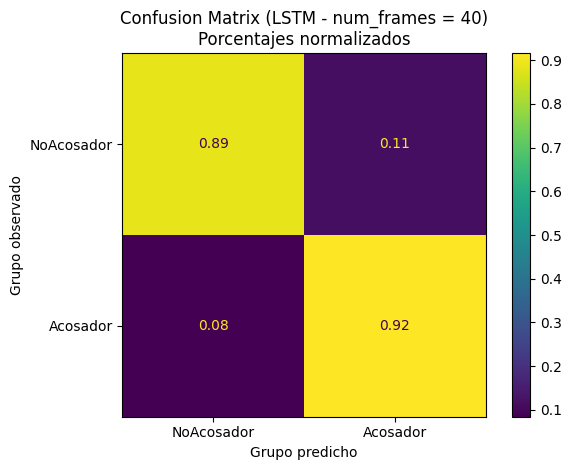

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Ajustamos el tamaño de la figura del gráfico
plt.figure(figsize=(8, 6))

# Obtenemos los resultados para un valor: num_frames=40, que obtuvo los mejores resultados
cm_raw = np.array(model_eval_results_lstm['confusion_matrix'])
# Normalizamos la matriz de Confusión para: 'true' (recall) normalization
cm_normalized = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['NoAcosador', 'Acosador'])
# Dibujar directamente: plt.gca() |  Otro colormap: cmap=plt.cm.Blues
disp.plot(values_format='.2f')
plt.title('Confusion Matrix (LSTM - num_frames = 40)\nPorcentajes normalizados')
plt.xlabel('Grupo predicho')
plt.ylabel('Grupo observado')
plt.grid(False)

plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

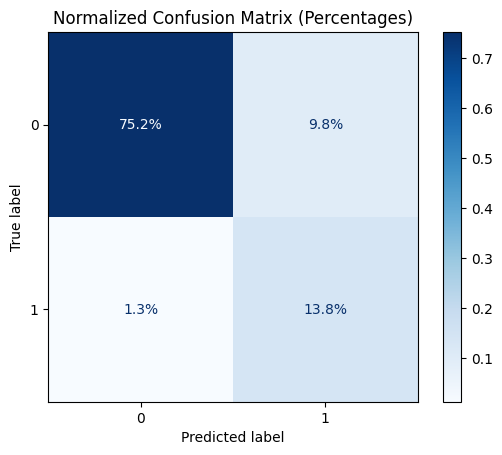

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Los valores: data_obs y data_pred, están disponibles de la ejecución previa
# Ajustamos el tamaño de la figura para mejorar la visibilidad
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(all_y_true, all_y_pred_classes, normalize='all', values_format='.1%', cmap='Blues')
plt.title('Matriz de Confusion Normalizada (Porcentajes)')
plt.show()

In [ ]:

model_eval_results_lstm.keys()


dict_keys(['training_history', 'confusion_matrix', 'classification_report', 'roc_curve_data'])

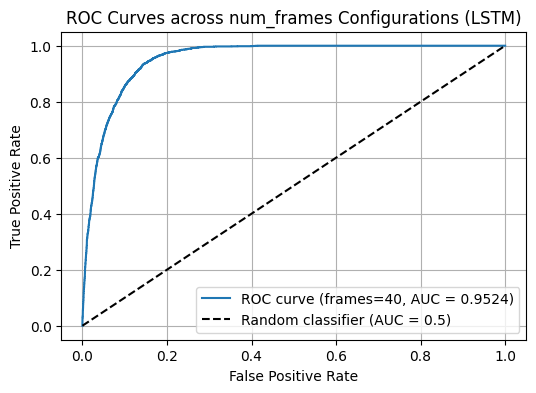

In [ ]:

import matplotlib.pyplot as plt

# Create a new matplotlib figure
plt.figure(figsize=(6, 4))

roc_data = model_eval_results_lstm['roc_curve_data']
fpr = roc_data['fpr']
tpr = roc_data['tpr']
roc_auc = roc_data['auc']
plt.plot(fpr, tpr, label=f'ROC curve (frames={num_frames}, AUC = {roc_auc:.4f})')

# Add a diagonal dashed line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.5)')

# Add title and labels
plt.title('ROC Curves across num_frames Configurations (LSTM)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Add legend and grid
plt.legend(loc="lower right")
plt.grid(True)

# Display the plot
plt.show()


#**GRÁFICO λ - ciclos de entrenamiento**

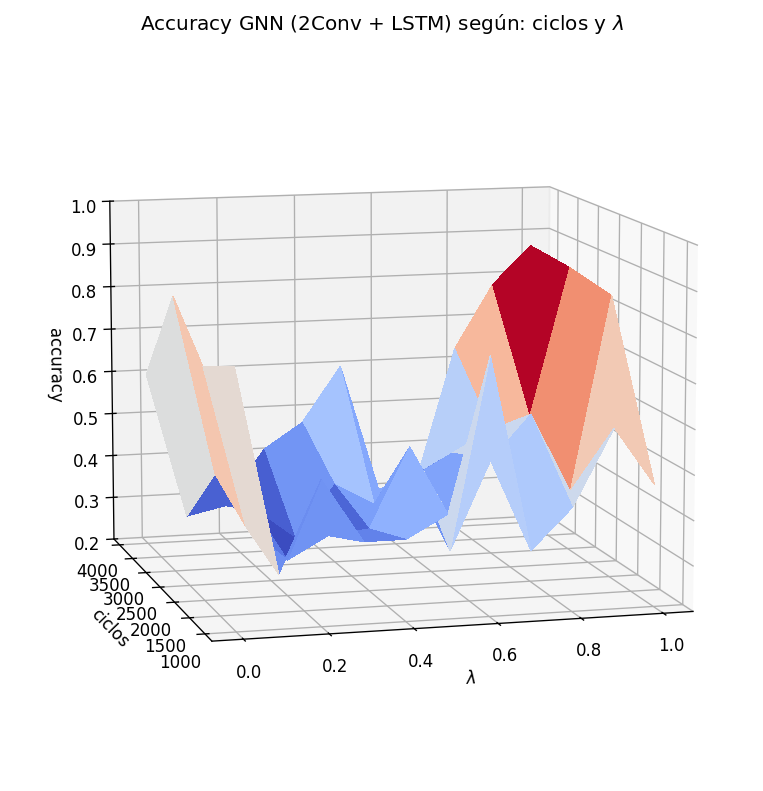

In [ ]:

import matplotlib.pylab as pl
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

import matplotlib as mpl
# 'azel', 'trackball', 'sphere', or 'arcball'
mpl.rcParams['axes3d.mouserotationstyle'] = 'trackball'

from matplotlib import cm

# Eje X
# ======
x_values   = np.linspace(0.0,1.0,11)
# Variable respuesta (unique y-coordinates for the surface)
y_values = np.array([1000., 2000., 3000., 4000.])

# Eje Z
# =====
z1   = [0.77, 0.32, 0.52, 0.38, 0.38, 0.43, 0.77, 0.34, 0.43, 0.60, 0.47] # 1000 ciclos
z2   = [0.72, 0.36, 0.28, 0.33, 0.34, 0.52, 0.28, 0.48, 0.58, 0.40, 0.84] # 2000 ciclos
z3   = [0.83, 0.42, 0.33, 0.26, 0.38, 0.33, 0.39, 0.44, 0.49, 0.52, 0.86] # 3000 ciclos
z4   = [0.60, 0.26, 0.28, 0.41, 0.47, 0.60, 0.30, 0.32, 0.63, 0.78, 0.87] # 4000 ciclos

Z_data = np.array([z1, z2, z3, z4])

# Create meshgrid using the x_values and y_values
X_mesh, Y_mesh = np.meshgrid(x_values, y_values)

# PLOTTING
# ========

pl.figure(figsize=(18, 8), dpi=120)
ax = pl.subplot(projection='3d')

ax.set_zlim(0.2,1.0)
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('ciclos')
ax.set_zlabel('accuracy')
ax.set_title('Accuracy GNN (2Conv + LSTM) según: ciclos y $\\lambda$')

surf = ax.plot_surface(X_mesh, Y_mesh, Z_data, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax.view_init(elev=10, azim=255, roll=0)
pl.show()


# Obtener la MATRIZ de CONFUSIÓN


In [ ]:

row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_row_normalized = cm_raw / row_sums

print("Matriz de Confusión original (cm_raw):")
print(cm_raw)
print("\nSuma por filas:")
print(row_sums)
print("\nMatriz de Confusión Normalizada por filas (cm_row_normalized):")
print(cm_row_normalized)

Original Confusion Matrix (cm_raw):
[[11791  1532]
 [  199  2158]]

Row Sums:
[[13323]
 [ 2357]]

Row-Normalized Confusion Matrix (cm_row_normalized):
[[0.88501088 0.11498912]
 [0.08442936 0.91557064]]



## Visualizar la Matriz de Confusión



<Figure size 800x600 with 0 Axes>

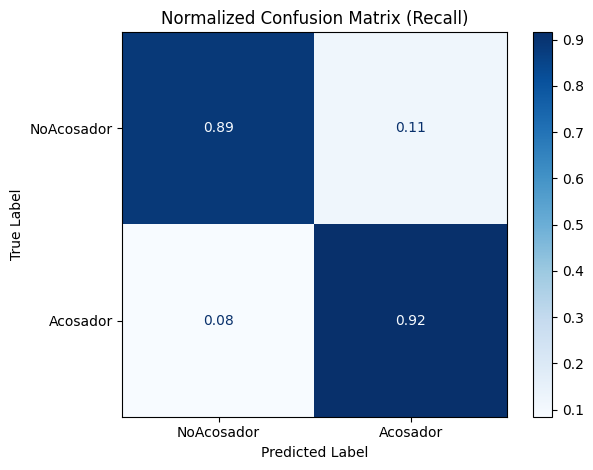

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_row_normalized, display_labels=['NoAcosador', 'Acosador'])
disp.plot(values_format='.2f', cmap='Blues')
plt.title('Matriz de Confusión Normalizada (Recall)')
plt.xlabel('Predicción')
plt.ylabel('Observado')
plt.grid(False)

plt.tight_layout()
plt.show()

## RESUMEN:

*   Matriz de confusión original (`cm_raw`):
    ```
    [[11791  1532]
     [  199  2158]]
    ```
*   La matriz de confusión: `cm_raw` fue correctamente normalizada por filas, dando lugar a `cm_row_normalized`, que representa el RECALL de cada clase.
    ```
    [[0.88501088 0.11498912]
     [0.08442936 0.91557064]]
    ```
*   Recall - clase 'NoAcosador' (Negativos Correctamente identificados): aproximadamente: 88.50%.
*   Recall - clase 'Acosador'   (Positivos correctamente identificados): aproximadamente: 91.56%.
*   La matriz de confusión normalizada por filas, proporciona una representación clara del RECALL de cada clase

Observaciones:
1) Buena RECALL para ambas clases, identificando correctamente a la clase 'ACOSADOR' ligeramente mejor que los individuos de la clase 'NO ACOSADOR'.

*   Further analysis could explore precision for each class to get a complete picture of the model's performance, especially if false positives have significant implications.
